In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut

In [11]:
#df = pd.read_csv('drive/MyDrive/GIZ_Irradiation_Project/Working Folder/models/CBE_Data/CBE_kenya.csv')
df = pd.read_csv('CBE_kenya.csv')

In [12]:
df.head()

,MEASURE_DATE,MEASURE_VALUE,SITE_COUNTRY,SITE_LATITUDE,SITE_LONGITUDE
0,2024-09-19,4763.700,Kenya,-0.400000,35.920000
1,2024-09-19,4243.524,Kenya,-1.494448,37.057094
2,2024-09-19,3860.330,Kenya,-1.491302,37.052862
3,2024-09-19,4764.821,Kenya,-1.451315,36.973008
4,2024-09-19,7052.209,Kenya,-0.227185,35.884984


In [13]:
df['MEASURE_DATE'] = pd.to_datetime(df['MEASURE_DATE'])
df = df.set_index('MEASURE_DATE')
df = df.sort_index()

df.head()

,MEASURE_VALUE,SITE_COUNTRY,SITE_LATITUDE,SITE_LONGITUDE
MEASURE_DATE,,,,
2017-04-01,0.0,Kenya,0.61,36.83
2017-04-02,0.0,Kenya,0.61,36.83
2017-04-03,0.0,Kenya,0.61,36.83
2017-04-04,0.0,Kenya,0.61,36.83
2017-04-05,0.0,Kenya,0.61,36.83


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 15272 entries, 2017-04-01 to 2024-11-25
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MEASURE_VALUE   15272 non-null  float64
 1   SITE_COUNTRY    15272 non-null  object 
 2   SITE_LATITUDE   15272 non-null  float64
 3   SITE_LONGITUDE  15272 non-null  float64
dtypes: float64(3), object(1)
memory usage: 596.6+ KB


In [15]:
# geolocator = Nominatim(user_agent="CBE-Kenya")

# def get_location_name(lat, lon):
#     try:
#         location = geolocator.reverse((lat, lon), exactly_one=True, timeout=10)
#         if location:
#             address = location.raw.get('address', {})
#             # Extract desired fields
#             city = address.get('city', '')
#             region = address.get('state', '')
#             return f"{city}, {region}"
#         return None
#     except GeocoderTimedOut:
#         return None


def add_unique_location_column(df, lat_col='latitude', lon_col='longitude'):
    """
    Adds a new column to the DataFrame with unique location names (e.g., 'Location 1', 'Location 2')
    based on latitude and longitude values.

    Args:
        df (pd.DataFrame): The DataFrame containing latitude and longitude columns.
        lat_col (str): Name of the column for latitude. Default is 'latitude'.
        lon_col (str): Name of the column for longitude. Default is 'longitude'.

    Returns:
        pd.DataFrame: The DataFrame with a new column 'location'.
    """
    # Create a unique identifier for each latitude-longitude pair
    unique_coords = {}
    location_counter = 1

    def get_location(lat, lon):
        nonlocal location_counter
        coord = (lat, lon)
        if coord not in unique_coords:
            unique_coords[coord] = f"Location {location_counter}"
            location_counter += 1
        return unique_coords[coord]

    df['location'] = df.apply(lambda row: get_location(row[lat_col], row[lon_col]), axis=1)
    return df

In [16]:
df_loc = add_unique_location_column(df, lat_col='SITE_LATITUDE', lon_col='SITE_LONGITUDE')


In [17]:
df_loc.head()

,MEASURE_VALUE,SITE_COUNTRY,SITE_LATITUDE,SITE_LONGITUDE,location
MEASURE_DATE,,,,,
2017-04-01,0.0,Kenya,0.61,36.83,Location 1
2017-04-02,0.0,Kenya,0.61,36.83,Location 1
2017-04-03,0.0,Kenya,0.61,36.83,Location 1
2017-04-04,0.0,Kenya,0.61,36.83,Location 1
2017-04-05,0.0,Kenya,0.61,36.83,Location 1


In [10]:
df_loc.tail()

,MEASURE_VALUE,SITE_COUNTRY,SITE_LATITUDE,SITE_LONGITUDE,location
MEASURE_DATE,,,,,
2024-11-25,1895.979,Kenya,-1.491302,37.052862,Location 13
2024-11-25,5546.946,Kenya,-0.982000,37.053900,Location 8
2024-11-25,2182.276,Kenya,-1.494448,37.057094,Location 11
2024-11-25,2213.580,Kenya,-1.494448,37.057094,Location 11
2024-11-25,4694.069,Kenya,-0.469974,35.181874,Location 3


#Plot 1

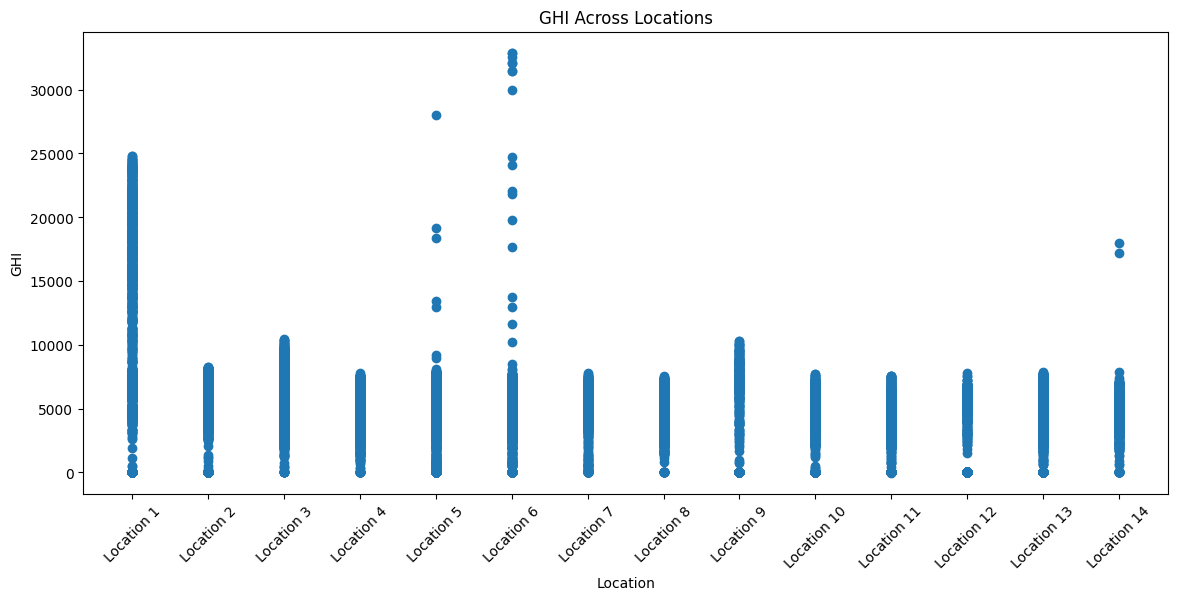

In [11]:
plt.figure(figsize=(14, 6))
plt.scatter(df['location'], df['MEASURE_VALUE'])
plt.xlabel('Location')
plt.ylabel('GHI')
plt.title('GHI Across Locations')
plt.xticks(rotation=45)
plt.show()

#Plot 2

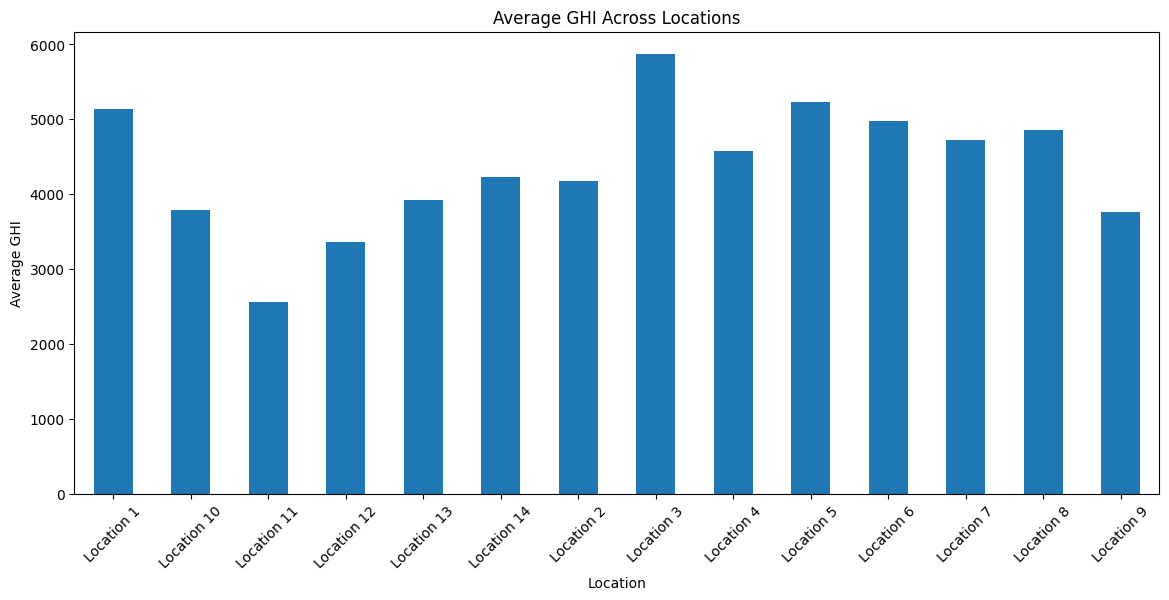

In [12]:
ghi_avg = df.groupby('location')['MEASURE_VALUE'].mean()

ghi_avg.plot(kind='bar', figsize=(14, 6))
plt.xlabel('Location')
plt.ylabel('Average GHI')
plt.title('Average GHI Across Locations')
plt.xticks(rotation=45)
plt.show()

##Box Plot

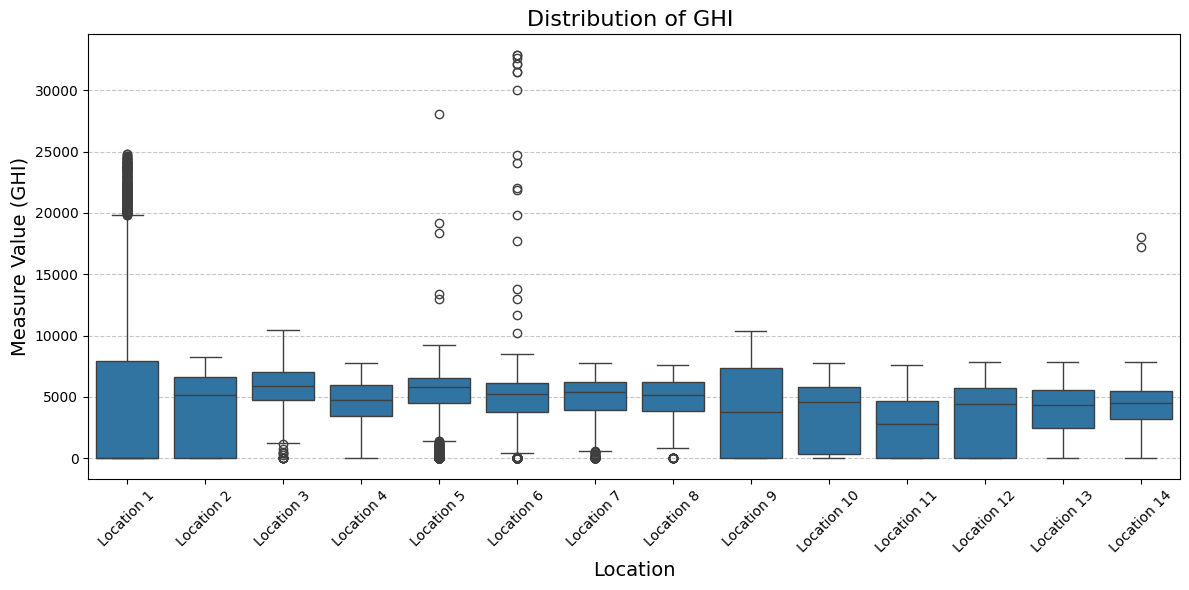

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='MEASURE_VALUE', data=df)

# Add labels and titles
plt.xlabel('Location', fontsize=14)
plt.ylabel('Measure Value (GHI)', fontsize=14)
plt.title('Distribution of GHI ', fontsize=16)
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


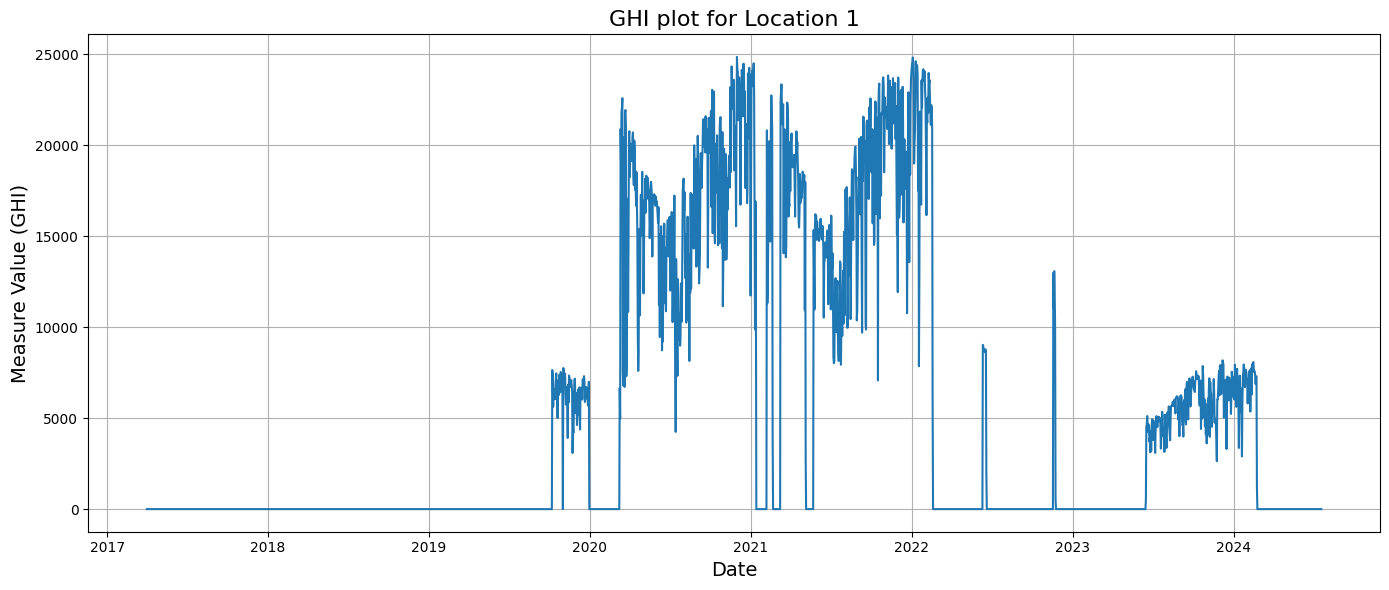

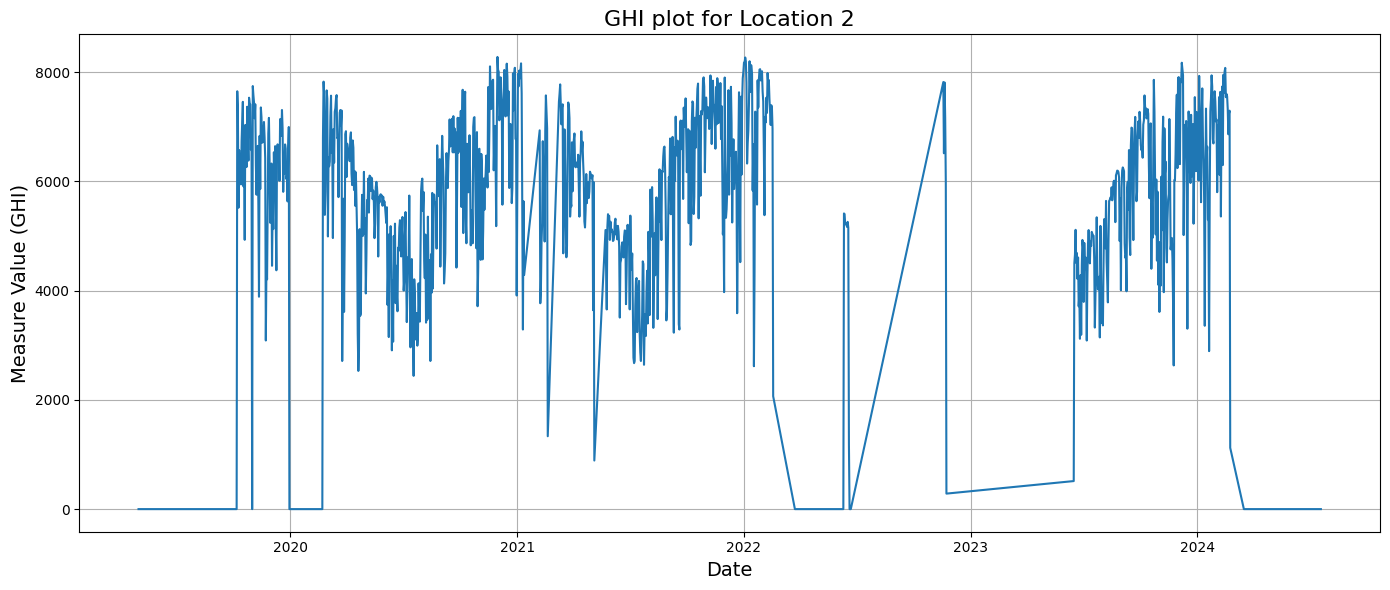

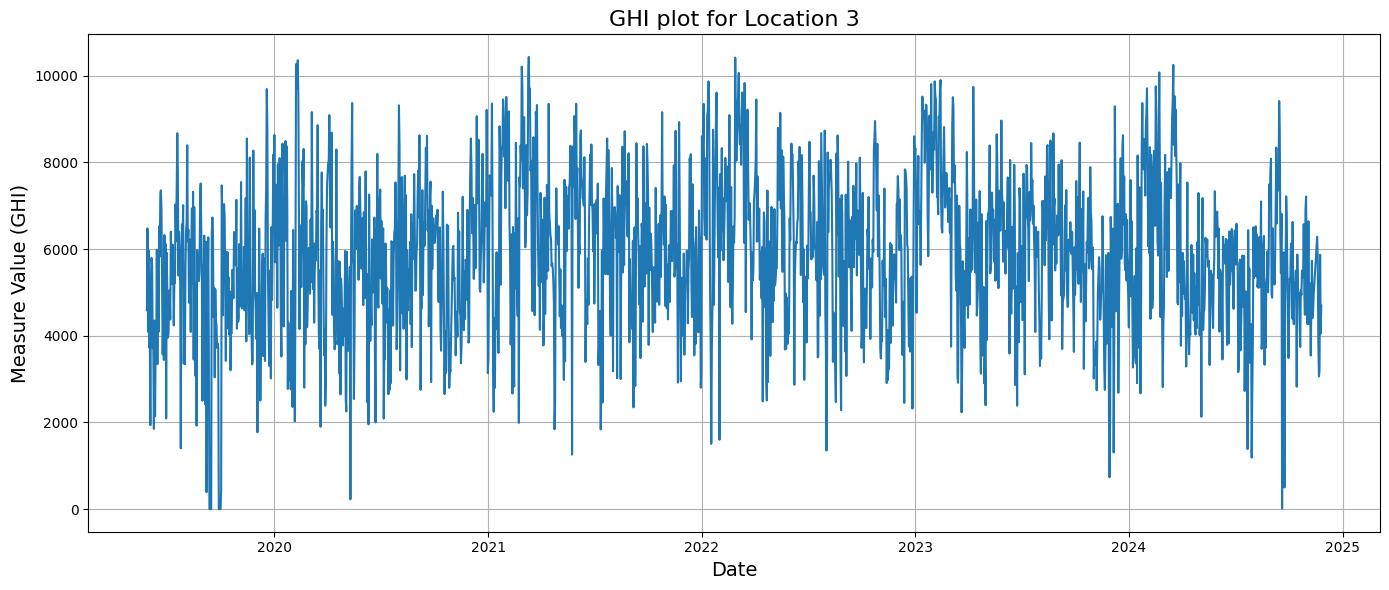

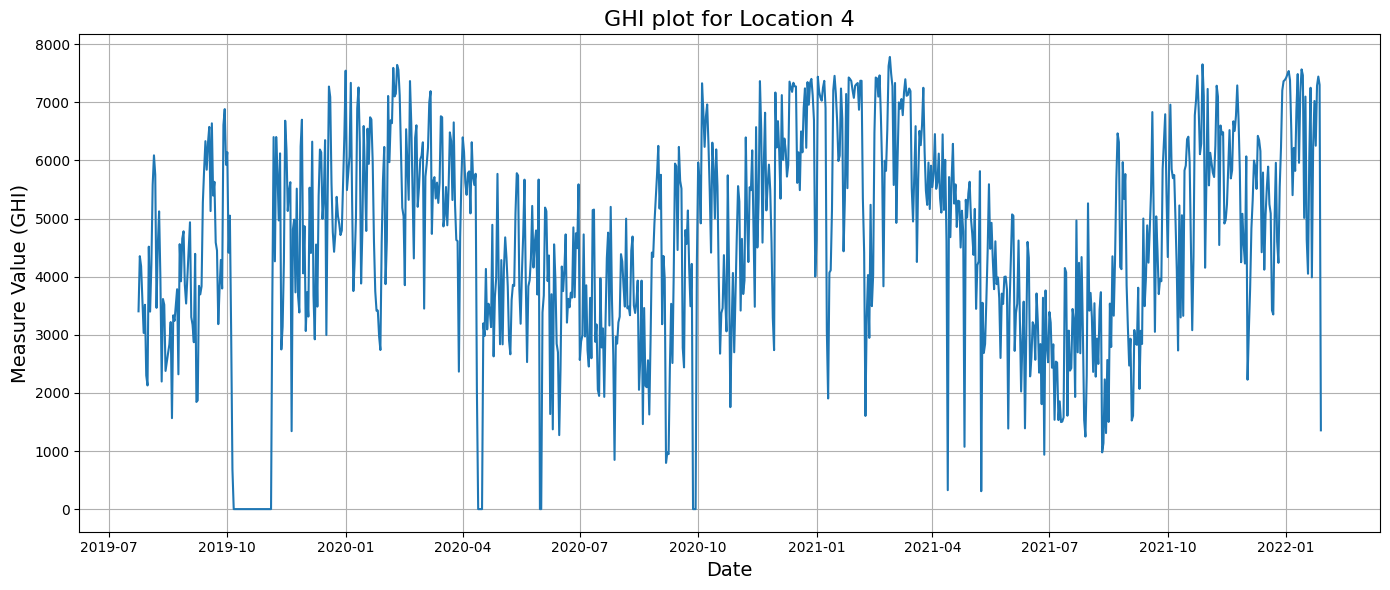

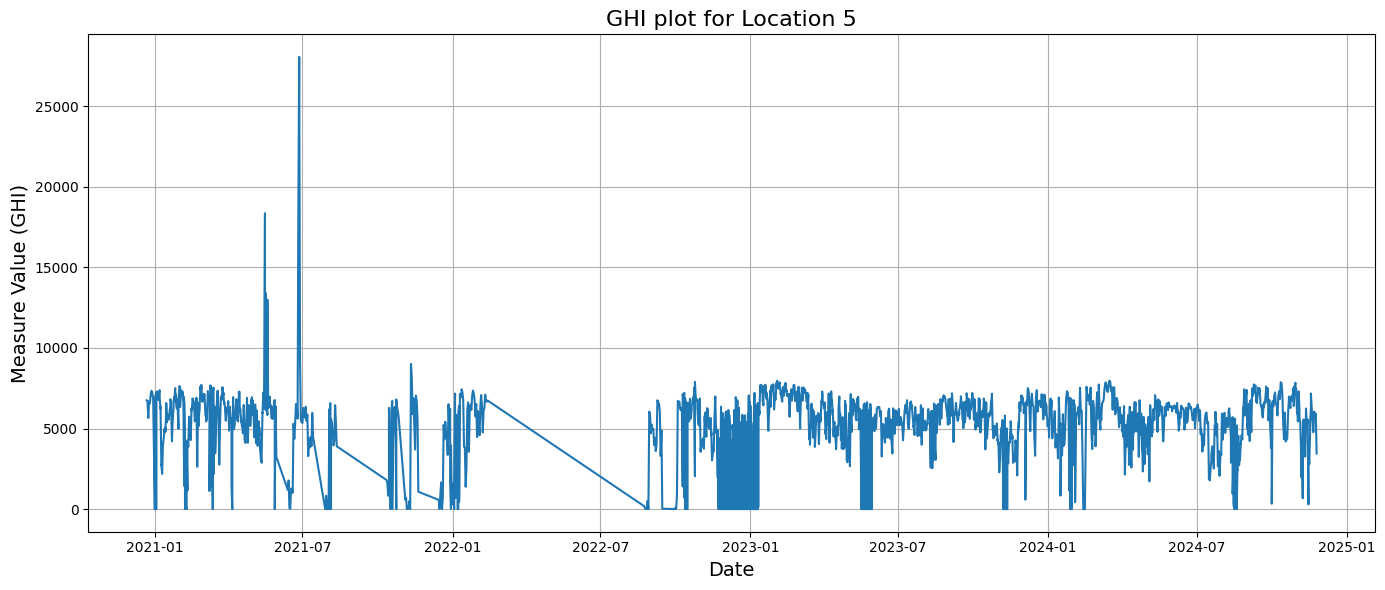

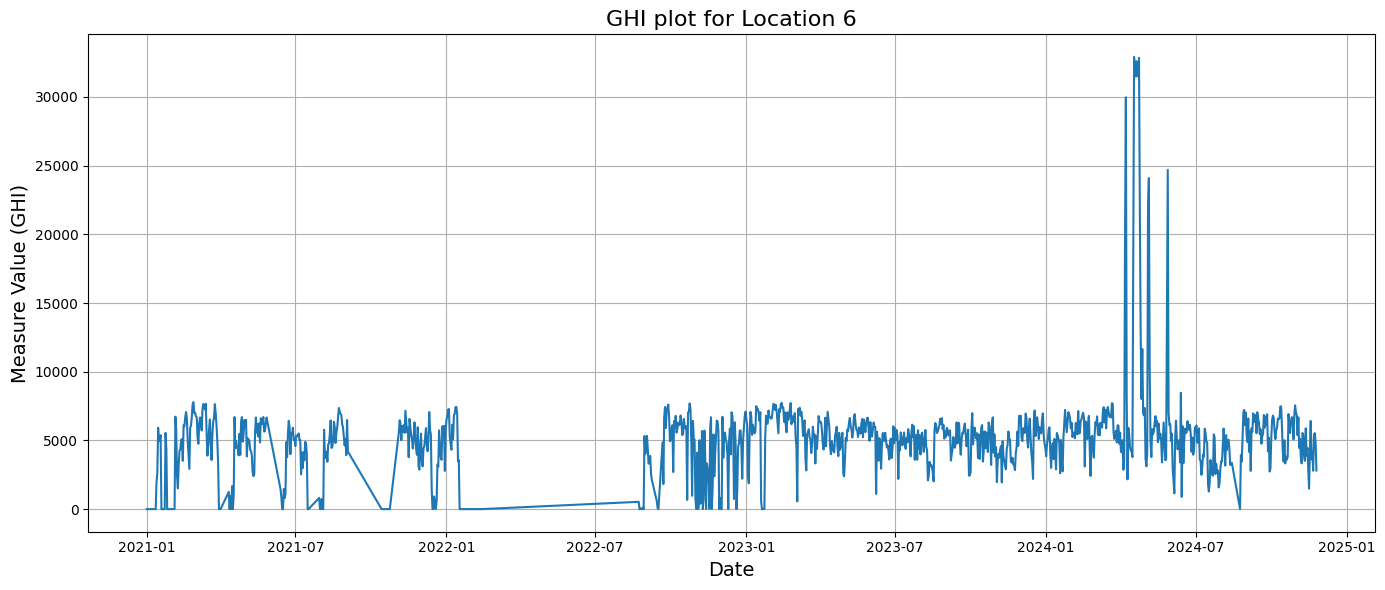

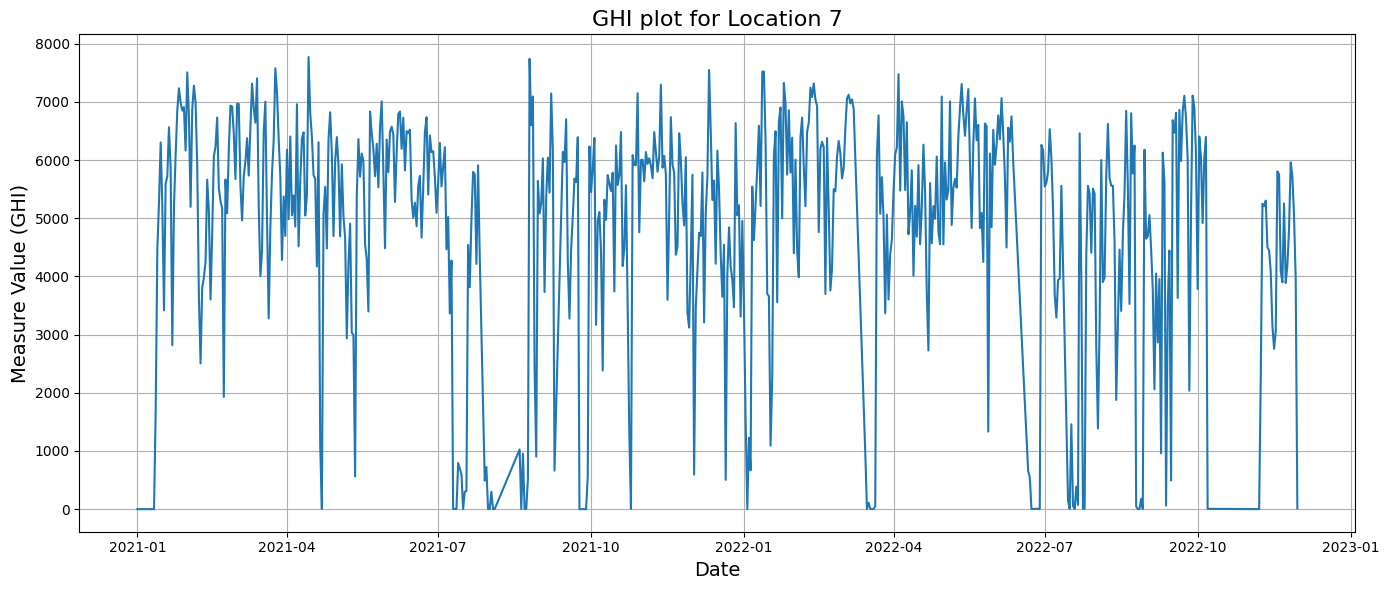

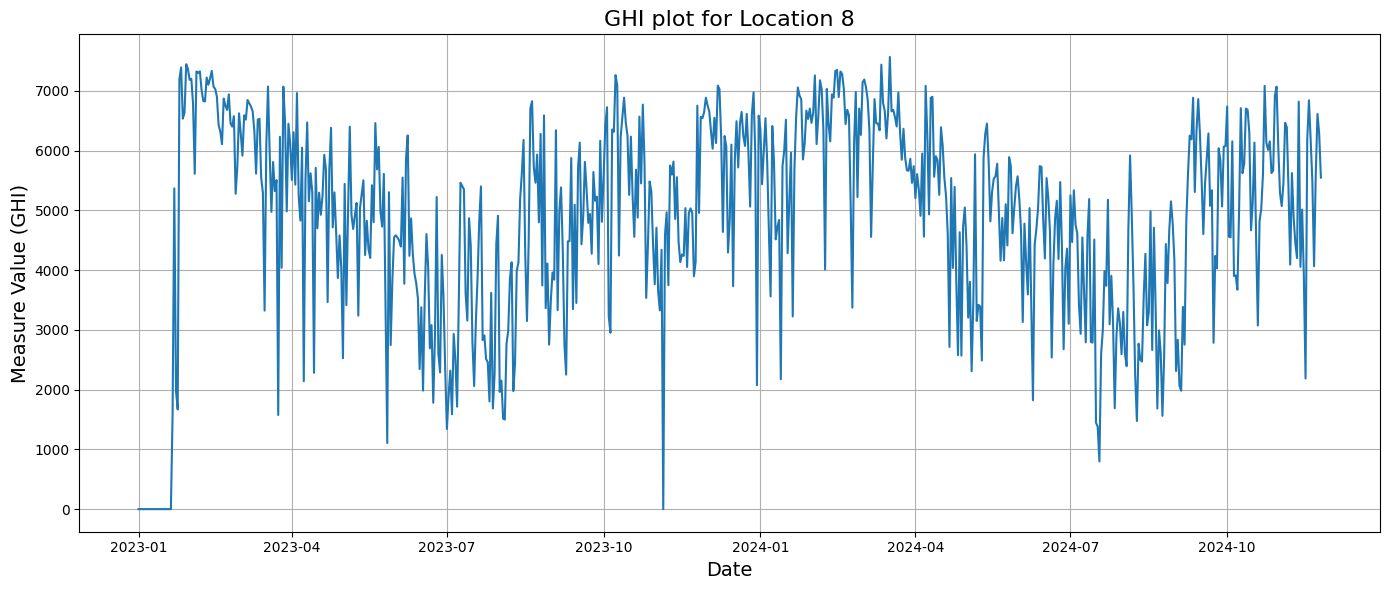

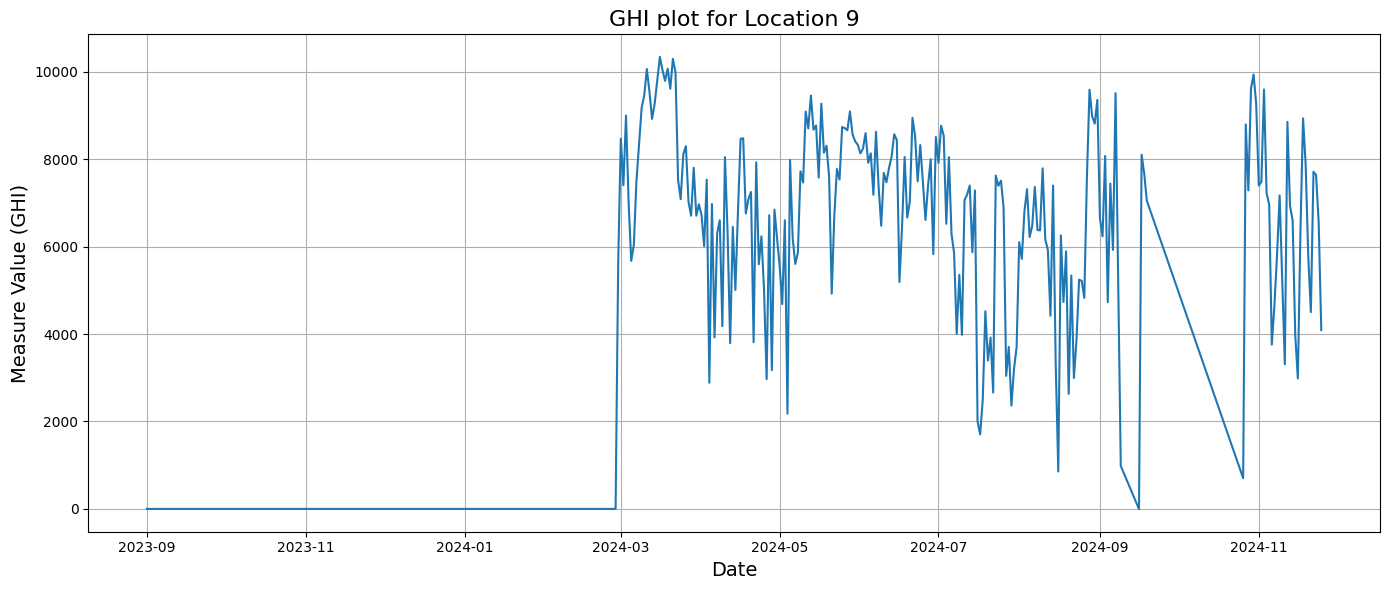

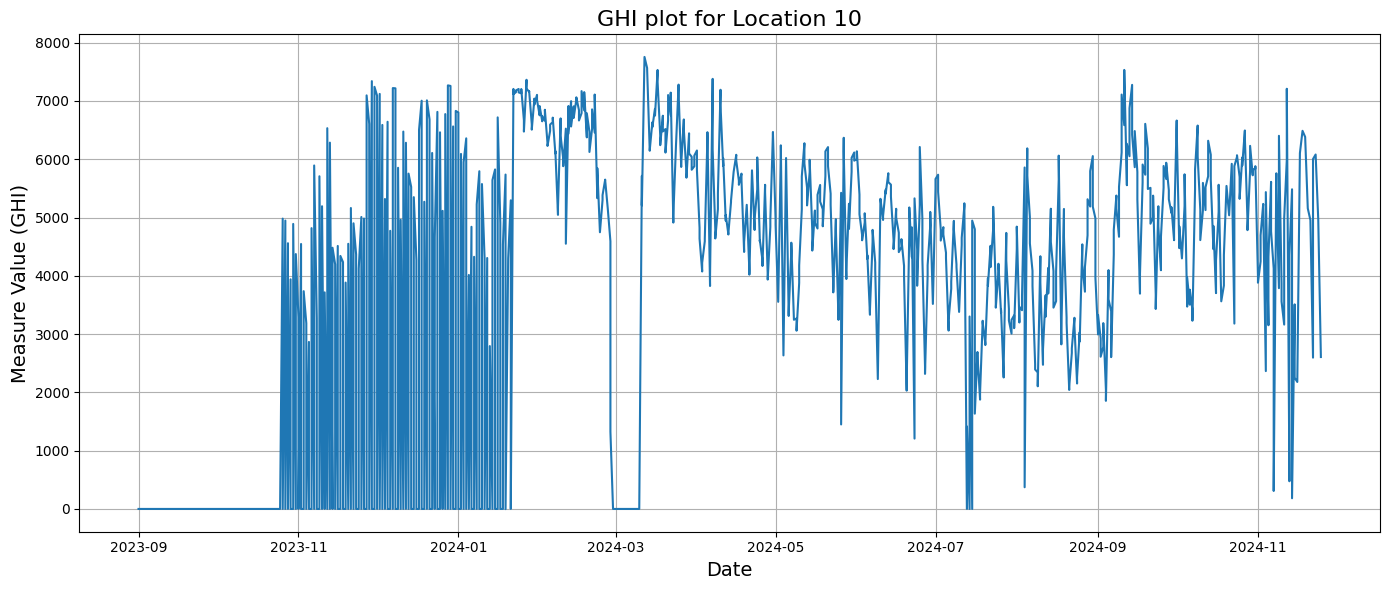

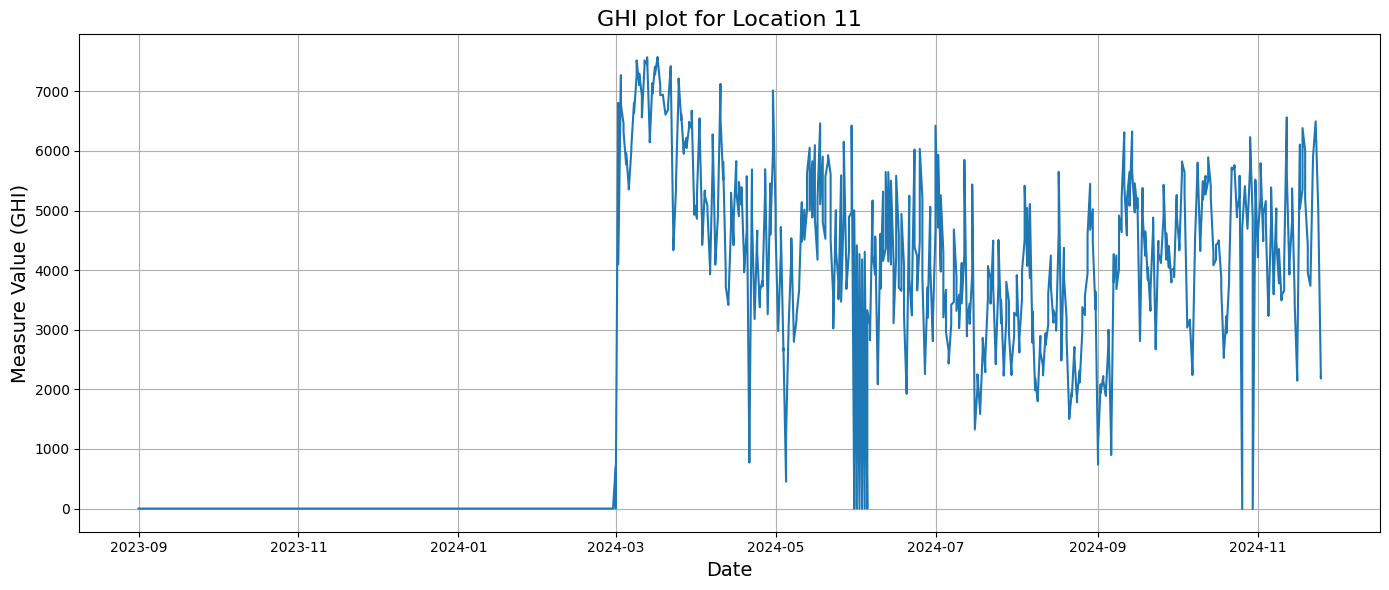

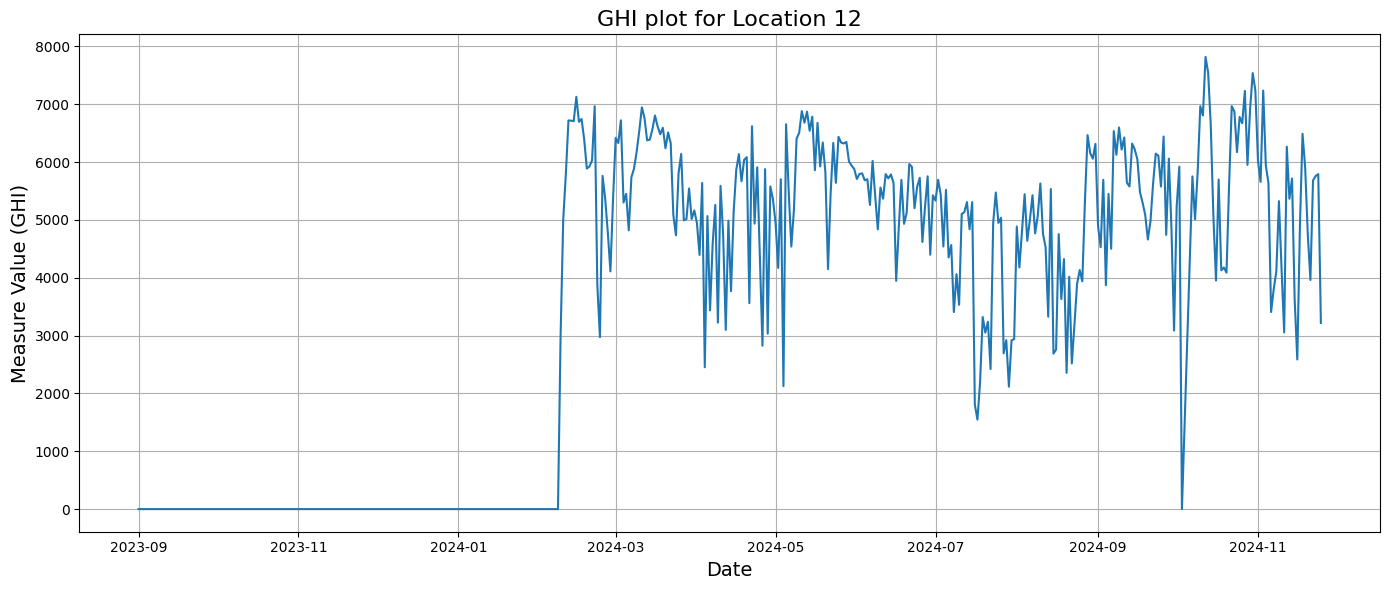

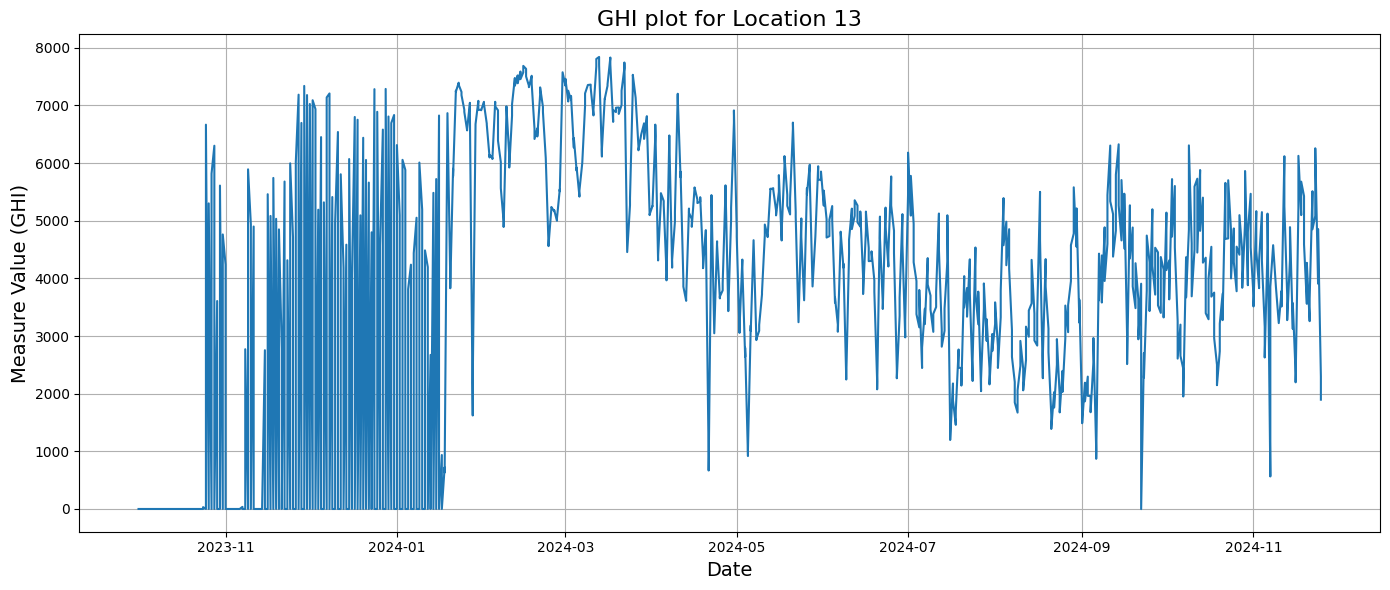

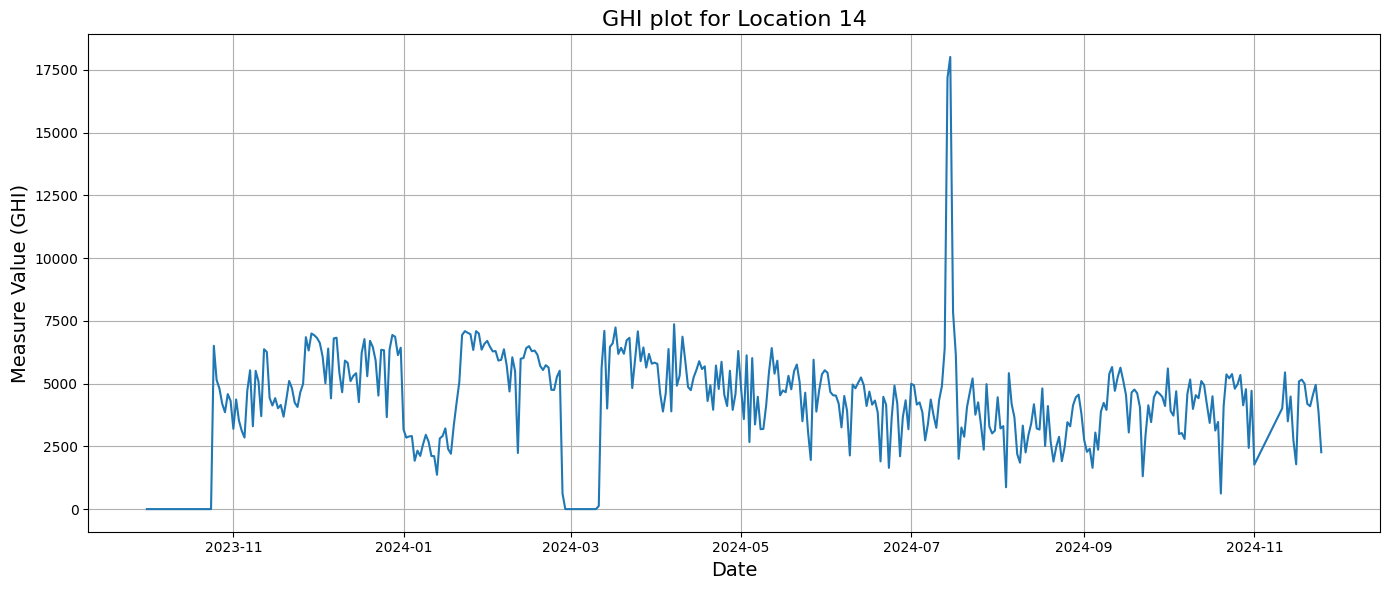

In [13]:
locations = df['location'].unique()


for location in locations:
    # Filter data for the current location
    location_data = df[df['location'] == location]

    # Create a new figure for each location
    plt.figure(figsize=(14, 6))
    plt.plot(location_data.index, location_data['MEASURE_VALUE'])

    # Add labels and titles
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Measure Value (GHI)', fontsize=14)
    plt.title(f'GHI plot for {location}', fontsize=16)
    plt.grid(True)
    plt.tight_layout()

    # Show the plot
    plt.show()

#Adding altitude

In [14]:
import requests

In [15]:
def get_elevation(lat, lon):
    url = f"https://api.open-elevation.com/api/v1/lookup?locations={lat},{lon}"
    response = requests.get(url)
    if response.status_code == 200:
        result = response.json()['results'][0]
        return result['elevation']  # Elevation in meters
    else:
        return None

cache = {}

def get_elevation_cached(lat, lon):
    coord = (lat, lon)
    if coord not in cache:
        cache[coord] = get_elevation(lat, lon)
    return cache[coord]

In [16]:
df['elevation'] = df.apply(lambda row: get_elevation_cached(row['SITE_LATITUDE'], row['SITE_LONGITUDE']), axis=1)
df.head()

,MEASURE_VALUE,SITE_COUNTRY,SITE_LATITUDE,SITE_LONGITUDE,location,elevation
MEASURE_DATE,,,,,,
2017-04-01,0.0,Kenya,0.61,36.83,Location 1,1688.0
2017-04-02,0.0,Kenya,0.61,36.83,Location 1,1688.0
2017-04-03,0.0,Kenya,0.61,36.83,Location 1,1688.0
2017-04-04,0.0,Kenya,0.61,36.83,Location 1,1688.0
2017-04-05,0.0,Kenya,0.61,36.83,Location 1,1688.0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 15272 entries, 2017-04-01 to 2024-11-25
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MEASURE_VALUE   15272 non-null  float64
 1   SITE_COUNTRY    15272 non-null  object 
 2   SITE_LATITUDE   15272 non-null  float64
 3   SITE_LONGITUDE  15272 non-null  float64
 4   location        15272 non-null  object 
 5   elevation       15272 non-null  float64
dtypes: float64(4), object(2)
memory usage: 835.2+ KB


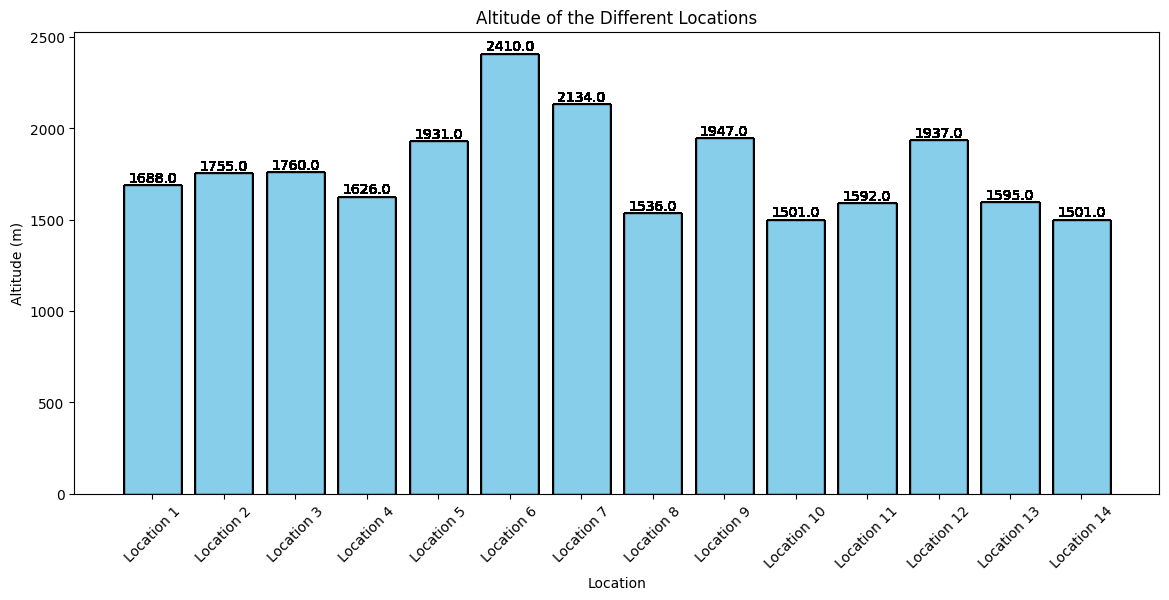

In [18]:
plt.figure(figsize=(14, 6))
bars = plt.bar(df['location'], df['elevation'], color='skyblue', edgecolor='black')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}',
             ha='center', va='bottom', fontsize=10)

plt.xlabel('Location')
plt.ylabel('Altitude (m)')
plt.title('Altitude of the Different Locations')
plt.xticks(rotation=45)
plt.show()

#Filter Dates

In [19]:
# start_date = '2020-01-01'
# end_date = '2022-12-31'

# # Filter the DataFrame for the date range using the index
# df_filtered = df[(df.index >= start_date) & (df.index <= end_date)]

# for location in locations:
#     # Filter data for the current location within the date range
#     location_data = df_filtered[df_filtered['location'] == location]

#     # Create a new figure for each location
#     plt.figure(figsize=(14, 6))

#     # Use the index for the x-axis
#     plt.plot(location_data.index, location_data['MEASURE_VALUE'])

#     # Add labels and titles
#     plt.xlabel('Date', fontsize=14)
#     plt.ylabel('Measure Value (GHI)', fontsize=14)
#     plt.title(f'GHI plot for {location} (2020-2022)', fontsize=16)
#     plt.grid(True)
#     plt.tight_layout()

#     # Show the plot
#     plt.show()

In [20]:
##Clustering the locations that are near each other by a distance of 50km

In [8]:
##Locations 1 and 2

In [24]:
locations = ['Location 1', 'Location 2']
years = [2020, 2021]

In [25]:
filtered_df = df[
    (df['location'].isin(locations)) &
    (df.index.year.isin(years))
]

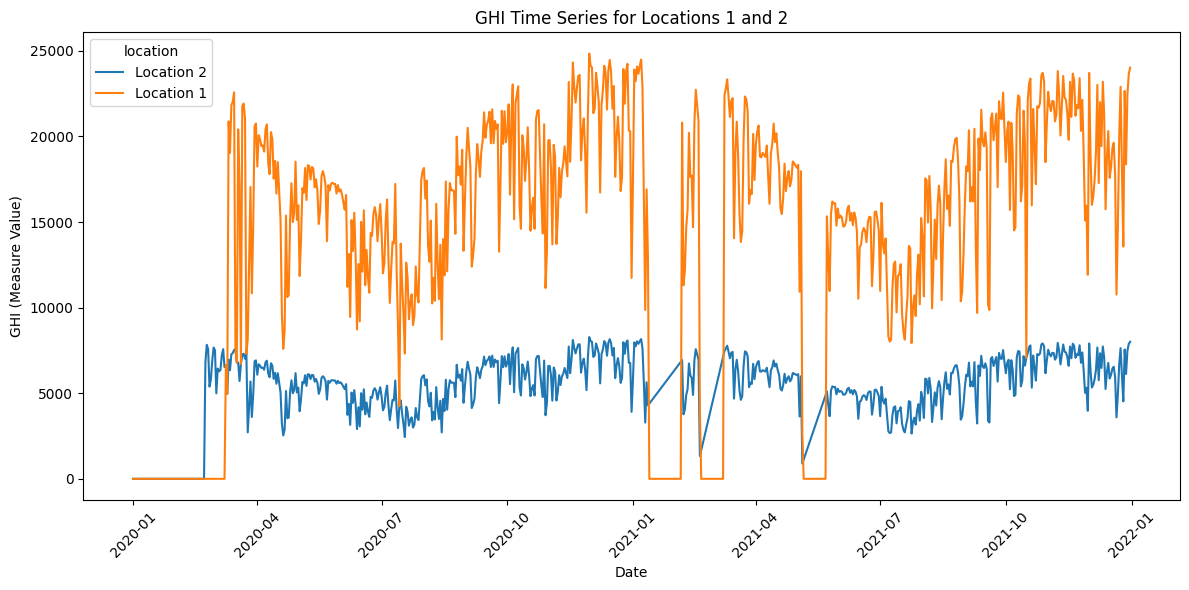

In [26]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=filtered_df, x='MEASURE_DATE', y='MEASURE_VALUE', hue='location')
plt.xlabel('Date')
plt.ylabel('GHI (Measure Value)')
plt.title('GHI Time Series for Locations 1 and 2')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Distance between the Locations

In [33]:
filtered_df.head()

,MEASURE_VALUE,SITE_COUNTRY,SITE_LATITUDE,SITE_LONGITUDE,location
MEASURE_DATE,,,,,
2020-01-01,0.0,Kenya,0.61,36.80,Location 2
2020-01-01,0.0,Kenya,0.61,36.83,Location 1
2020-01-02,0.0,Kenya,0.61,36.83,Location 1
2020-01-02,0.0,Kenya,0.61,36.80,Location 2
2020-01-03,0.0,Kenya,0.61,36.80,Location 2


In [27]:
from geopy.distance import geodesic

In [35]:
loc_1 = 'Location 1'
latitude_1 = df.loc[df['location'] == loc_1, 'SITE_LATITUDE'].values[0]
longitude_1 = df.loc[df['location'] == loc_1, 'SITE_LONGITUDE'].values[0]

loc_2 = 'Location 2'
latitude_2 = df.loc[df['location'] == loc_2, 'SITE_LATITUDE'].values[0]
longitude_2 = df.loc[df['location'] == loc_2, 'SITE_LONGITUDE'].values[0]

# print(latitude_1, longitude_1, latitude_2, longitude_2)

In [34]:
location_2 = [latitude_2, longitude_2]
location_1 = [latitude_1, longitude_1]
distance = geodesic(location_1, location_2).km
print(f"Distance: {distance:.2f} km")

Distance: 3.34 km


In [37]:
##Locations 11 & 13

In [39]:
locations_2 = ['Location 13', 'Location 11']
years_2 = [2024]

In [43]:
df_2 = df[
    (df['location'].isin(locations_2)) &
    (df.index.year.isin(years_2))
] 

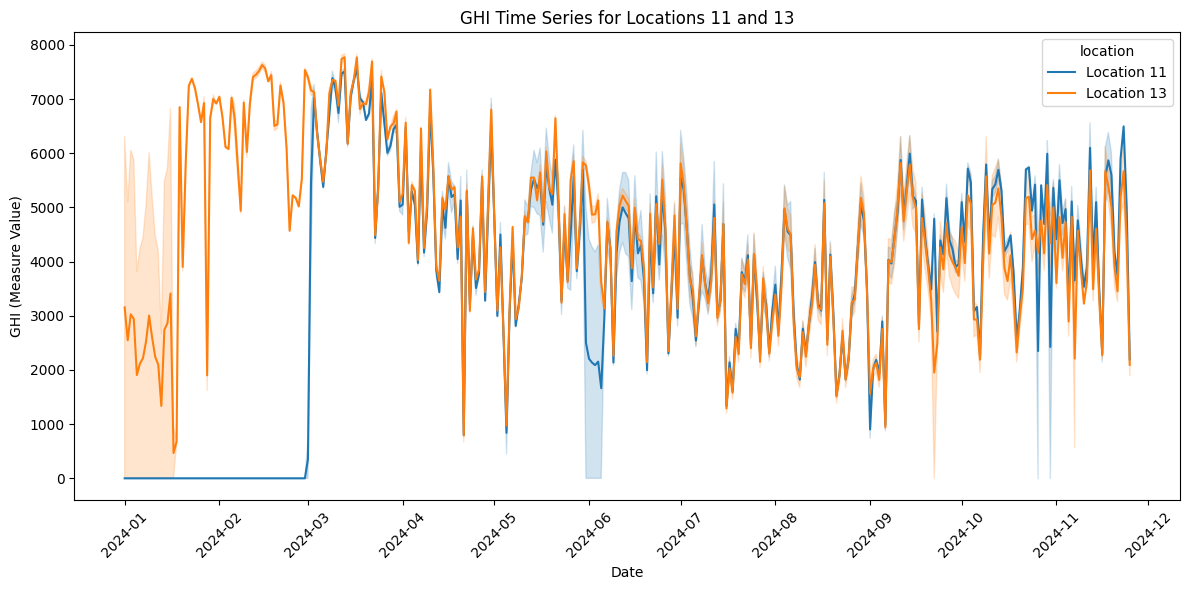

In [45]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_2, x='MEASURE_DATE', y='MEASURE_VALUE', hue='location')
plt.xlabel('Date')
plt.ylabel('GHI (Measure Value)')
plt.title('GHI Time Series for Locations 11 and 13')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
##Distance between the locations

In [46]:
loc_11 = 'Location 11'
latitude_11 = df.loc[df['location'] == loc_11, 'SITE_LATITUDE'].values[0]
longitude_11 = df.loc[df['location'] == loc_11, 'SITE_LONGITUDE'].values[0]

loc_13 = 'Location 13'
latitude_13 = df.loc[df['location'] == loc_13, 'SITE_LATITUDE'].values[0]
longitude_13 = df.loc[df['location'] == loc_13, 'SITE_LONGITUDE'].values[0]

location_11 = [latitude_11, longitude_11]
location_13 = [latitude_13, longitude_13]
distance = geodesic(location_11, location_13).km
print(f"Distance: {distance:.2f} km")

Distance: 0.59 km


In [ ]:
##Location 10 & 14

In [47]:
locations_3 = ['Location 10', 'Location 14']
years_3 = [2024]

df_3 = df[
    (df['location'].isin(locations_3)) &
    (df.index.year.isin(years_3))
] 

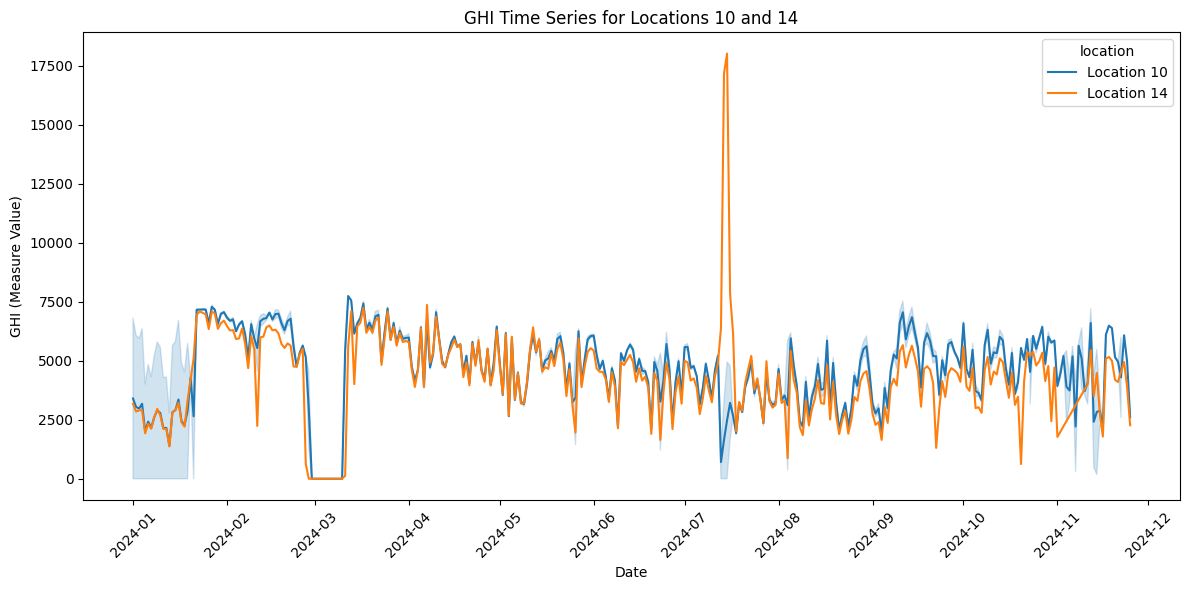

In [48]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_3, x='MEASURE_DATE', y='MEASURE_VALUE', hue='location')
plt.xlabel('Date')
plt.ylabel('GHI (Measure Value)')
plt.title('GHI Time Series for Locations 10 and 14')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
##locations 12, 9, 5, 7

In [51]:
multi_locations = ['Location 12', 'Location 9', 'Location 5']
years_multi = [2024]

df_multi = df[
    (df['location'].isin(multi_locations)) &
    (df.index.year.isin(years_multi))
] 

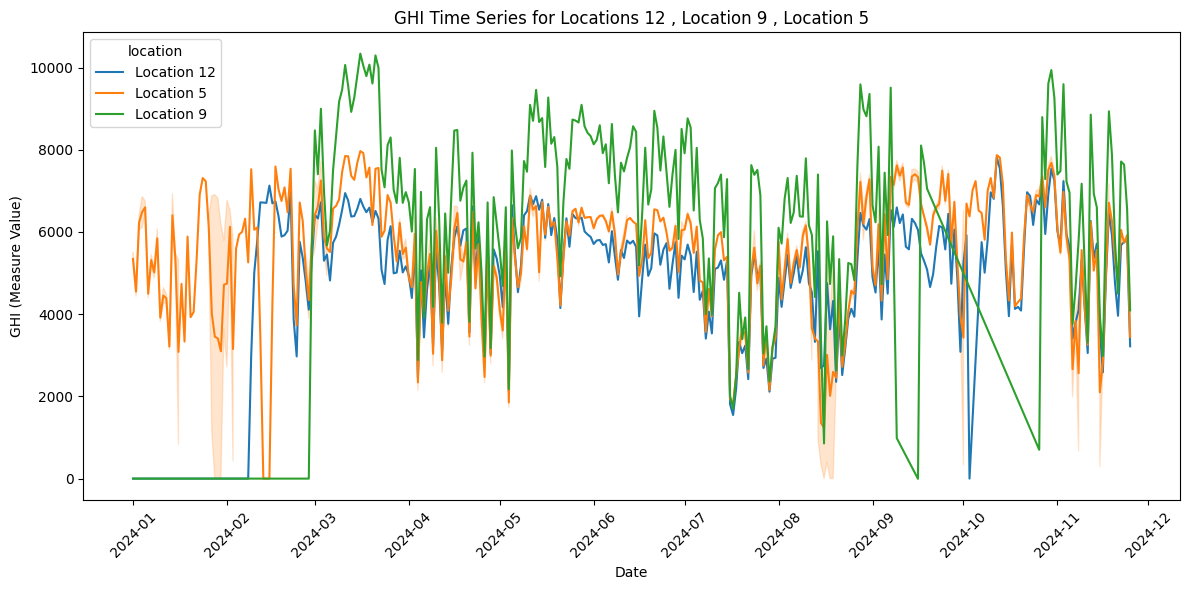

In [53]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_multi, x='MEASURE_DATE', y='MEASURE_VALUE', hue='location')
plt.xlabel('Date')
plt.ylabel('GHI (Measure Value)')
plt.title('GHI Time Series for Locations 12 , Location 9 , Location 5')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Other Parameters

In [ ]:
from susse.api_clients import ModisDataFetcher
from susse.api_clients import ModisProductEnum
from datetime import datetime

In [ ]:

geolocator = Nominatim(user_agent="SuSSe")
location = geolocator.geocode("Kampala")
start_date = datetime(2022, 1, 1)
end_date = datetime(2022, 1, 25)

data_fetcher = ModisDataFetcher()
result = data_fetcher.fetch_surface_reflectance(location, start_date, end_date)
print(result)

In [ ]:
result.to_np()

In [ ]:
location

In [ ]:
dates = data_fetcher.get_available_dates_for_product_and_location(ModisProductEnum.SURFACE_REFLACTANCE, location)

In [ ]:
ModisProductEnum.SURFACE_REFLACTANCE.value